<div>
<img src=https://www.institutedata.com/wp-content/uploads/2019/10/iod_h_tp_primary_c.svg width="300">
</div>

# Lab 6.5
## Feature Selection

### Data

**Predict the onset of diabetes based on diagnostic measures.**

This dataset is originally from the National Institute of Diabetes and Digestive and Kidney Diseases. The objective of the dataset is to diagnostically predict whether or not a patient has diabetes, based on certain diagnostic measurements included in the dataset. Several constraints were placed on the selection of these instances from a larger database. In particular, all patients here are females at least 21 years old of Pima Indian heritage.

[Pima Indians Diabetes Database](https://www.kaggle.com/uciml/pima-indians-diabetes-database/download)

In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Load Data

In [3]:
# Read Data
from google.colab import files
uploaded = files.upload()

diabetes_csv = 'diabetes.csv'
df=pd.read_csv(diabetes_csv)

Saving diabetes.csv to diabetes.csv


#### 2. Perform EDA

Perform EDA. Check Null Values. Impute if necessary.

In [4]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


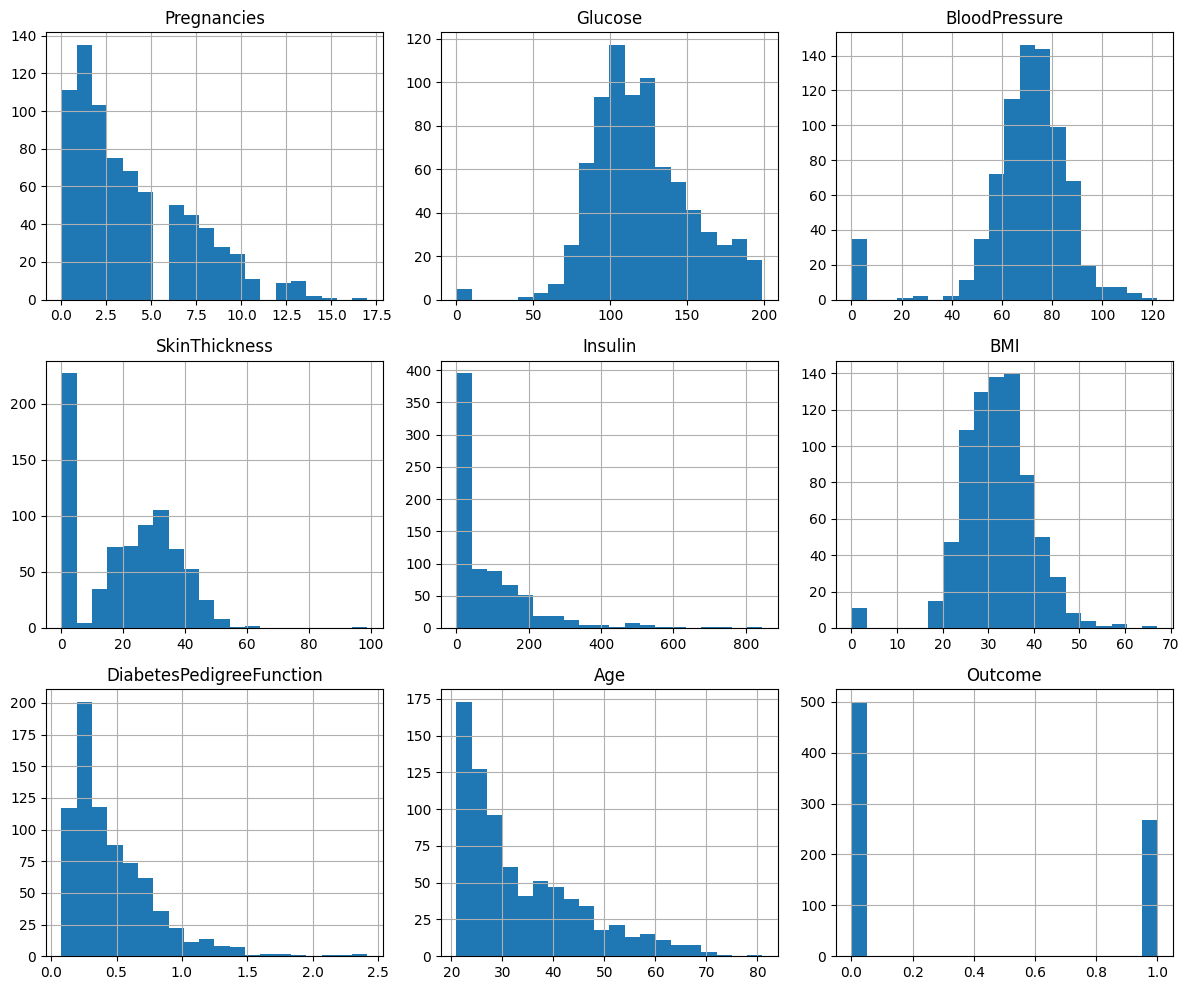

In [7]:
# Histograms of all features
df.hist(figsize=(12,10), bins=20)
plt.tight_layout()
plt.show()

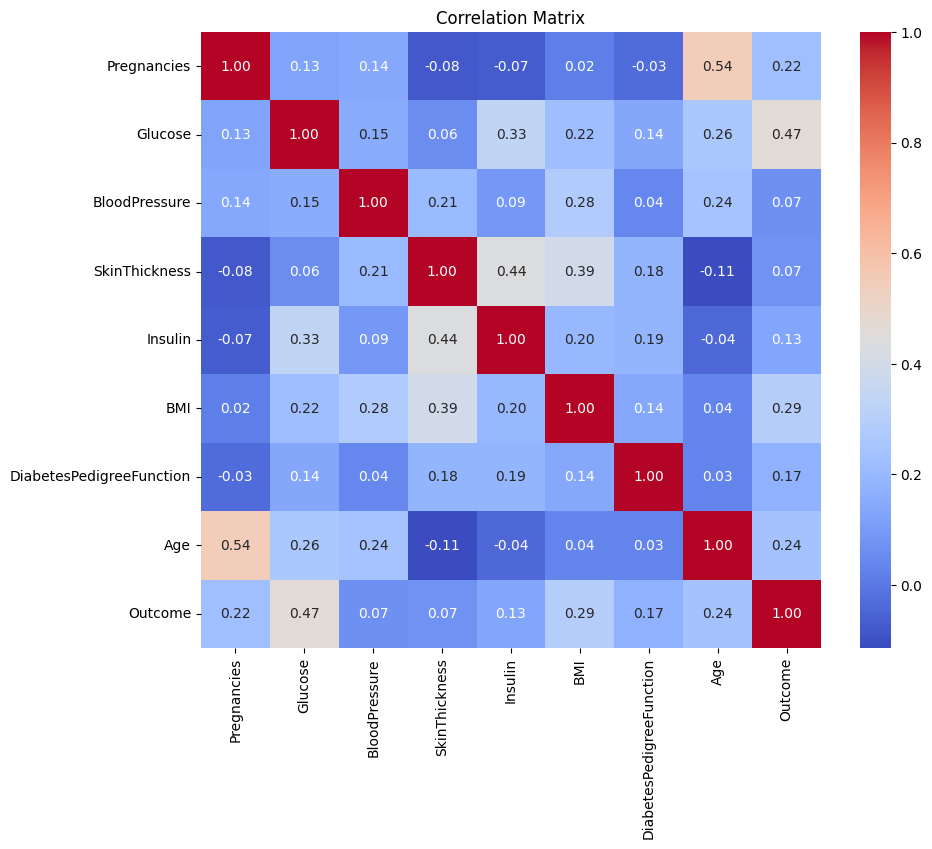

In [8]:
# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

#### 3. Set Target

- Set `Outcome` as target.
- Set Features

In [10]:
# Set target variable
y = df['Outcome']

# Set feature variables
X = df.drop('Outcome', axis=1)

#### 4. Select Feature

The classes in the sklearn.feature_selection module can be used for feature selection/dimensionality reduction on sample sets, either to improve estimators’ accuracy scores or to boost their performance on very high-dimensional datasets.

##### 4.1 Univariate Selection

Univariate feature selection works by selecting the best features based on univariate statistical tests. It can be seen as a preprocessing step to an estimator. Scikit-learn exposes feature selection routines as objects that implement the transform method:

- SelectKBest removes all but the  highest scoring features
- Use sklearn.feature_selection.chi2 as score function
    > Recall that the chi-square test measures dependence between stochastic variables, so using this function “weeds out” the features that are the most likely to be independent of class and therefore irrelevant for classification.


More Reads:
[Univariate feature selection](https://scikit-learn.org/stable/modules/feature_selection.html)

- Create an instance of SelectKBest
    - Use sklearn.feature_selection.chi2 as score_func
    - Use k of your choice
- Fit X, y
- Find top 4 features
- Transform features to a DataFrame

In [11]:
# Create an instance of SelectKBest
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
selector = SelectKBest(score_func=chi2, k=4)

In [12]:
# Fit
selector.fit(X, y)

SelectKBest(k=4, score_func=<function chi2 at 0x7e474d4ee020>)

In [13]:
# Print Score
feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Chi2 Score': selector.scores_
}).sort_values(by='Chi2 Score', ascending=False)
print("Chi2 Scores for All Features:")
print(feature_scores)

# Find Top 4 Features
top_features = feature_scores['Feature'].iloc[:4].tolist()
print("\nTop 4 Features:", top_features)

Chi2 Scores for All Features:
                    Feature   Chi2 Score
4                   Insulin  2175.565273
1                   Glucose  1411.887041
7                       Age   181.303689
5                       BMI   127.669343
0               Pregnancies   111.519691
3             SkinThickness    53.108040
2             BloodPressure    17.605373
6  DiabetesPedigreeFunction     5.392682

Top 4 Features: ['Insulin', 'Glucose', 'Age', 'BMI']


In [14]:
# Transform X to Features
X_selected = selector.transform(X)

In [15]:
# Transform features to a dataframe
X_selected_df = pd.DataFrame(X_selected, columns=top_features)

##### 4.2 Recursive feature elimination

Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), recursive feature elimination (RFE) is to select features by recursively considering smaller and smaller sets of features. First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through a coef_ attribute or through a feature_importances_ attribute. Then, the least important features are pruned from current set of features. That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.

More Reads:
[Recursive feature elimination](https://scikit-learn.org/stable/modules/feature_selection.html)

- Use RFE to extract feature
    - use LogisticRegression as estimator
    - Number of n_features_to_select as of your choice
- Fit X, y to RFE
- Find Selected Features

In [17]:
# ANSWER
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [19]:
# Print Score
# Scale the features manually
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Create logistic regression model
log_reg = LogisticRegression(max_iter=500, solver='liblinear')

# Create RFE selector
selector = RFE(estimator=log_reg, n_features_to_select=5, step=1)

# Fit RFE
selector.fit(X_scaled, y)

# Get RFE results
rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': selector.support_,
    'Rank': selector.ranking_
}).sort_values(by='Rank')

print("RFE Feature Ranking:")
print(rfe_results)

# Find Features
# Transform data to keep only selected features
X_rfe = selector.transform(X_scaled)

# Get selected feature names
selected_features = rfe_results.loc[rfe_results['Selected'], 'Feature'].tolist()
print("\nSelected Features:", selected_features)


RFE Feature Ranking:
                    Feature  Selected  Rank
0               Pregnancies      True     1
1                   Glucose      True     1
2             BloodPressure      True     1
5                       BMI      True     1
6  DiabetesPedigreeFunction      True     1
7                       Age     False     2
4                   Insulin     False     3
3             SkinThickness     False     4

Selected Features: ['Pregnancies', 'Glucose', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction']




---



---



> > > > > > > > > © 2025 Institute of Data


---



---



